In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime

from src.cashflows.cashflow_bucketer import CashflowBucketer

In [2]:
# load portfolio cashflows
portfolio_cf = pd.read_csv('../data/processed/portfolio_cashflows.csv')
portfolio_cf

,Unnamed: 0,date,principal,interest,total_cashflow,outstanding_balance,instrument_type
0,0,2026-03-01,750.657847,1175.000000,1925.657847,2.992493e+05,asset
1,1,2026-04-01,753.597923,1172.059923,1925.657847,2.984957e+05,asset
2,2,2026-05-01,756.549515,1169.108332,1925.657847,2.977392e+05,asset
3,3,2026-06-01,759.512668,1166.145179,1925.657847,2.969797e+05,asset
4,4,2026-07-01,762.487426,1163.170421,1925.657847,2.962172e+05,asset
...,...,...,...,...,...,...,...
257,16,2030-04-01,261028.073744,21909.100306,282937.174050,1.087224e+06,liability
258,17,2030-07-01,265269.779942,17667.394108,282937.174050,8.219545e+05,liability
259,18,2030-10-01,269580.413866,13356.760184,282937.174050,5.523741e+05,liability
260,19,2031-01-01,273961.095591,8976.078459,282937.174050,2.784130e+05,liability


In [3]:
# initialize cf bucketer
valuation_date = datetime(2026, 3, 1)
bucketer = CashflowBucketer(
    valuation_date = valuation_date
)

bucketed_cf = bucketer.bucket_cashflows(
    portfolio_cf = portfolio_cf
)

bucketed_cf

,bucket,asset_cf,liability_cf,gap,cumulative_gap
0,1M,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
1,3M,3851.315694,2.829372e+05,-2.790859e+05,-2.790859e+05
2,6M,5776.973541,2.829372e+05,-2.771602e+05,-5.562461e+05
3,1Y,13479.604928,5.658743e+05,-5.523947e+05,-1.108641e+06
4,2Y,21182.236316,1.131749e+06,-1.110566e+06,-2.219207e+06
5,3Y,23107.894163,1.131749e+06,-1.108641e+06,-3.327848e+06
6,5Y,48141.446173,2.546435e+06,-2.498293e+06,-5.826141e+06
7,7Y,44290.130479,0.000000e+00,4.429013e+04,-5.781851e+06
8,10Y,69323.682489,0.000000e+00,6.932368e+04,-5.712527e+06
9,15Y,115539.470814,0.000000e+00,1.155395e+05,-5.596988e+06


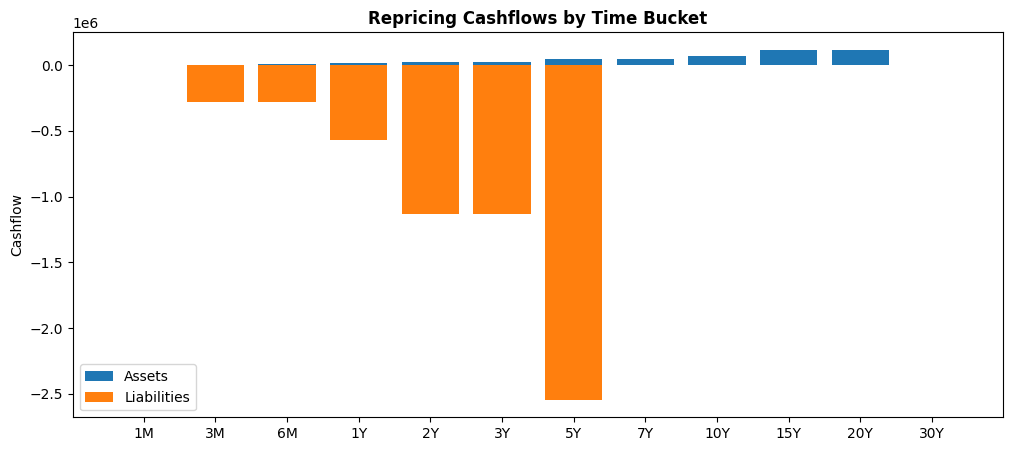

In [ ]:
# plotting Assets vs Liabilities per bucket
plt.figure(figsize = (12, 5))
x = bucketed_cf['bucket']

plt.bar(x, bucketed_cf['asset_cf'], label='Assets')
plt.bar(x, -bucketed_cf['liability_cf'], label='Liabilities')

plt.title("Repricing Cashflows by Time Bucket", fontweight = 'bold')
plt.ylabel("Cashflow")
plt.legend()
plt.show()

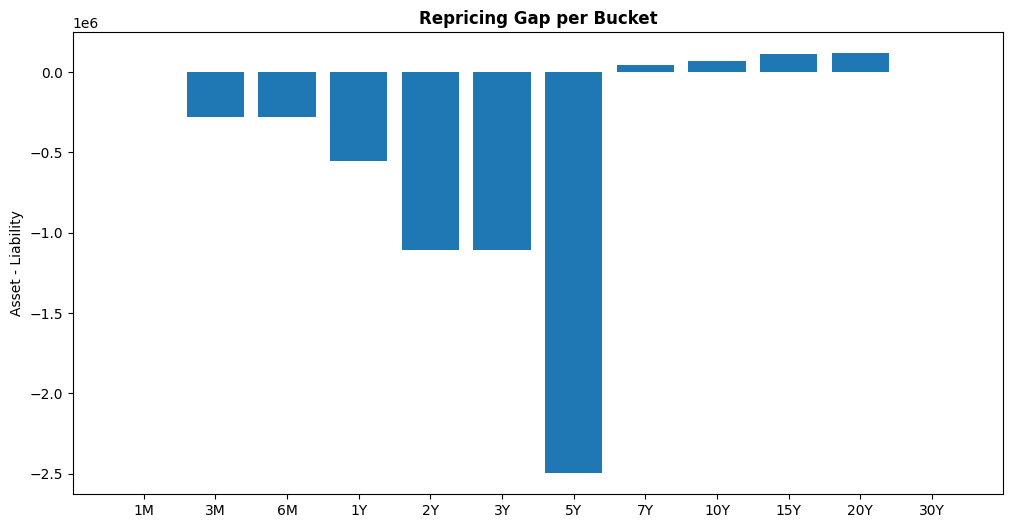

In [7]:
# plotting repricing gap per bucket
plt.figure(figsize = (12, 6))
plt.bar(
    bucketed_cf['bucket'],
    bucketed_cf['gap']
)

plt.title("Repricing Gap per Bucket", fontweight = 'bold')
plt.ylabel('Asset - Liability')
plt.show()

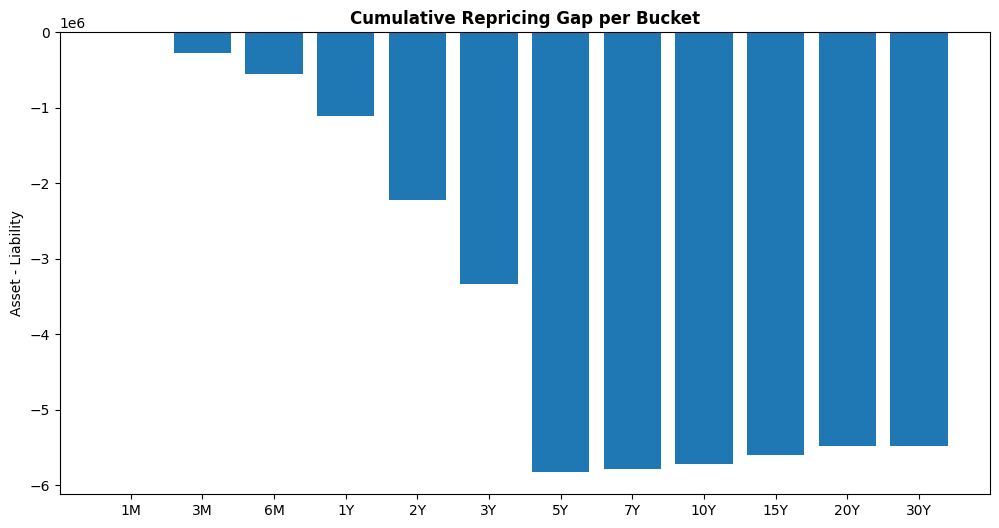

In [8]:
# plotting cumulative repricing gap per bucket
plt.figure(figsize = (12, 6))
plt.bar(
    bucketed_cf['bucket'],
    bucketed_cf['cumulative_gap']
)

plt.title("Cumulative Repricing Gap per Bucket", fontweight = 'bold')
plt.ylabel('Asset - Liability')
plt.show()